# 0.2 — Rearranging for ANY Symbol, at the computer

Do the **pen-and-paper worksheet first**. Here you learn the two ways to check a
rearrangement: the **round trip** (random numbers) and the **sympy referee**.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")     # lets Python find our shared plotting helpers

import numpy as np
import matplotlib.pyplot as plt
from plots import plot_functions

## 1. The round-trip check

A rearrangement claims two formulas say the same thing. So: run the original *forwards*,
run yours *backwards*, and you must land exactly where you started — for ANY numbers.
That's the answer to worksheet 0.1's bonus question: no numbers? Invent some.

In [2]:
# v = a*t, rearranged for a:  a = v/t
a, t = 2.5, 4.0            # any numbers at all (t not zero — we noted that assumption!)
v = a * t                  # forwards with the original
a_check = v / t            # backwards with the rearrangement
print("landed back on a?", a_check == a)

landed back on a? True


In [3]:
# YOUR TURN — round-trip your worksheet Part B answers.
# Problem 5 (y = m*x + b, solved for x) is set up; do 6 and 7 the same way.

m, b, x = 3.0, 1.5, 7.0
y = m * x + b
x_check = 0        # <- replace 0 with YOUR rearrangement, written in Python
print("P5 lands back on x?", x_check == x)

# P6: A = (1/2)*b*h, solved for h     (pick your own numbers for A's inputs)
# P7: F = (9/5)*C + 32, solved for C  (sanity check: C=100 should give F=212)

P5 lands back on x? False


## 2. The sympy referee

sympy plays the balance game with *pure symbols* — exactly the game you played on paper.
`sp.solve(equation, symbol)` means "rearrange this for that symbol".

In [4]:
import sympy as sp

# declare every letter as a symbol (positive=True tells sympy r, A are positive,
# so it keeps only the + square root — like you did on paper)
y, m, x, b = sp.symbols("y m x b")
A, r = sp.symbols("A r", positive=True)
d, a, t = sp.symbols("d a t", positive=True)

print("P5  x =", sp.solve(sp.Eq(y, m*x + b), x))          # y = mx + b
print("P8  r =", sp.solve(sp.Eq(A, sp.pi * r**2), r))     # A = pi r^2
print("P9  t =", sp.solve(sp.Eq(d, sp.Rational(1, 2) * a * t**2), t))

P5  x = [(-b + y)/m]
P8  r = [sqrt(A)/sqrt(pi)]
P9  t = [sqrt(2)*sqrt(d)/sqrt(a)]


In [5]:
# YOUR TURN — referee your Part D attempts (13–15).
# Problem 13 is done; write 14 and 15 yourself.
k, c, eta, eta0 = sp.symbols("k c eta eta_0", positive=True)

print("P13 x =", sp.solve(sp.Eq(k/x + c, y), x))

# P14: y = (a + b)/a, solve for a   (declare fresh symbols if you need them)
# P15: eta = eta0 / (1 + k*t), solve for t

P13 x = [k/(-c + y)]


## 3. 🌀 What a rearrangement LOOKS like

$A = \pi r^2$ and its rearrangement $r = \sqrt{A/\pi}$ aren't two facts — they're **one
relationship read in two directions**. Plot both and something lovely appears: each is the
other's mirror image across the diagonal line $y = x$. Every legal rearrangement hides
this symmetry.

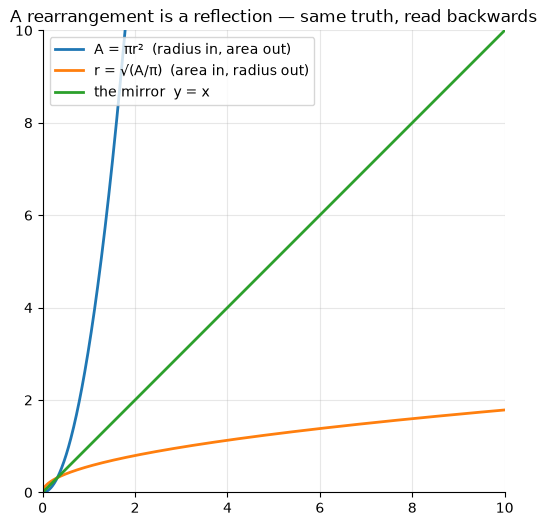

In [6]:
ax = plot_functions({
    "A = \u03c0r\u00b2  (radius in, area out)": lambda r: np.pi * r**2,
    "r = \u221a(A/\u03c0)  (area in, radius out)": lambda A: np.sqrt(np.clip(A, 0, None) / np.pi),
    "the mirror  y = x": lambda x: x,
}, xlim=(0, 10), ylim=(0, 10))
ax.set_title("A rearrangement is a reflection — same truth, read backwards")
plt.show()

Two formulas, one curve-pair, perfectly mirrored. In Module 1 this idea gets a name —
*inverse functions* — and in Module 5 you'll see a neural net's forward pass and its
training step play the same forwards/backwards duet.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 0.3 — expand & factor, the old wound gets fixed.*